<a href="https://colab.research.google.com/github/devesssi/llm-diffusion-models-finetuning/blob/main/hack_ps1(classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install transformers torch

In [ ]:
from transformers import pipeline

# Specify the model name
model_name = "Wutterfly/roberta-privacy-policy-context"

# Load the model using pipeline
# The task 'text-classification' is assumed based on the model name context
# You might need to adjust the task if the model is for a different purpose (e.g., 'question-answering', 'fill-mask')
classifier = pipeline("text-classification", model=model_name)

print(f"Model '{model_name}' loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/295 [00:00<?, ?B/s]

Device set to use cuda:0


Model 'Wutterfly/roberta-privacy-policy-context' loaded successfully.


Now that the model is loaded, you can perform inference. Here's an example:

In [ ]:
# Example input text
example_text = "We collect personal information such as your name, email address, and payment details to provide our services and for billing purposes."

# Perform inference
results = classifier(example_text)

# Display the results
print("Inference results:")
for result in results:
    print(f"  Label: {result['label']}, Score: {result['score']:.4f}")

Inference results:
  Label: Services, Score: 0.9895


# Task
Fine-tune the `Wutterfly/roberta-privacy-policy-context` model for sequence classification using the `sjsq/PrivacyPolicy` dataset, evaluating its performance with metrics like accuracy, precision, recall, and F1-score.

## Install Libraries

### Subtask:
Install necessary libraries like `datasets` and `transformers` for loading the dataset and finetuning the model.


**Reasoning**:
To install the `datasets` library, I will use the `pip install` command in a code block.



In [ ]:
pip install datasets

Both `datasets` and `transformers` libraries are now installed. The `transformers` library was installed earlier in the notebook.

## Load Dataset

### Subtask:
Load the `sjsq/PrivacyPolicy` dataset using the `datasets` library.


**Reasoning**:
To load the 'sjsq/PrivacyPolicy' dataset, I will import the `load_dataset` function from the `datasets` library and then use it to load the specified dataset.



In [ ]:
from datasets import load_dataset

# Load the 'sjsq/PrivacyPolicy' dataset
dataset = load_dataset('sjsq/PrivacyPolicy')

print("Dataset 'sjsq/PrivacyPolicy' loaded successfully.")
print(dataset)

README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Multilabel%20DS.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1789 [00:00<?, ? examples/s]

Dataset 'sjsq/PrivacyPolicy' loaded successfully.
DatasetDict({
    train: Dataset({
        features: ['Null', 'filename', 'Text', 'Category', 'Purpose', 'Personal Information Type', 'Collection Mode', 'Action First-Party', 'Third Party Entity', 'Action Third Party'],
        num_rows: 1789
    })
})


## Inspect Dataset

### Subtask:
Inspect the loaded dataset to understand its structure, features, and example data. This will help determine how to prepare it for finetuning.


**Reasoning**:
To inspect the dataset as requested, I will print the dataset keys, features of the train split, a few examples, and the unique categories present in the dataset.



In [ ]:
print("Dataset Keys:", dataset.keys())

# Access the 'train' split and print its features
train_dataset = dataset['train']
print("\nFeatures of the 'train' split:", train_dataset.features)

# Display the first few examples from the 'train' split
print("\nFirst 5 examples from 'train' split:")
for i in range(5):
    print(f"Example {i+1}:")
    print(f"  Text: {train_dataset[i]['Text']}")
    print(f"  Category: {train_dataset[i]['Category']}")
    print("\n")

# Inspect the unique values in the 'Category' column
print("Unique categories in 'train' split:", set(train_dataset['Category']))

Dataset Keys: dict_keys(['train'])

Features of the 'train' split: {'Null': Value('int64'), 'filename': Value('string'), 'Text': Value('string'), 'Category': Value('string'), 'Purpose': Value('string'), 'Personal Information Type': Value('string'), 'Collection Mode': Value('string'), 'Action First-Party': Value('string'), 'Third Party Entity': Value('string'), 'Action Third Party': Value('string')}

First 5 examples from 'train' split:
Example 1:
  Text: Privacy Policy  
  Category: ['Introductory/Generic']


Example 2:
  Text:  Important Update    In September 2012, we announced that Instagram had been acquired by Facebook. We knew that by teaming up with Facebook, we could build a better Instagram for you. Since then, we've been collaborating with Facebook's team on ways to do just that. As part of our new collaboration, we've learned that by being able to share insights and information with each other, we can build better experiences for our users.  
  Category: []


Example 3:
  Te

The dataset inspection successfully revealed its structure, including the `Text` and `Category` columns. It's clear that the `Category` column contains labels that are represented as strings of lists, and some entries are empty lists. For example, `"['Introductory/Generic']"` or `"[]"`. This format will require parsing and conversion into a multi-hot encoded format suitable for multi-label classification.

The dataset inspection successfully revealed its structure, including the `Text` and `Category` columns. It's clear that the `Category` column contains labels that are represented as strings of lists, and some entries are empty lists. For example, `"['Introductory/Generic']"` or `"[]"`. This format will require parsing and conversion into a multi-hot encoded format suitable for multi-label classification.

## Prepare Dataset for Finetuning

### Subtask:
Preprocess the dataset by tokenizing the text and encoding the labels. This step will also involve creating a train and validation split if not already present, and formatting the dataset for the Hugging Face Trainer.


**Reasoning**:
The first step is to define a function to extract all unique labels from the 'Category' column, which is currently stored as a string representation of lists. This involves safely parsing these strings into actual Python lists and collecting all distinct categories. After extracting the unique labels, I will create `label2id` and `id2label` mappings, which are essential for encoding the labels into numerical format required for model training.



In [ ]:
import ast

def extract_unique_labels(dataset_split):
    unique_labels = set()
    for item in dataset_split['Category']:
        if item:
            try:
                # Safely evaluate the string representation of a list
                labels_list = ast.literal_eval(item)
                if isinstance(labels_list, list):
                    for label in labels_list:
                        unique_labels.add(label)
            except (ValueError, SyntaxError):
                # Handle cases where the string might not be a valid list representation
                # or if it's a single string that wasn't wrapped in a list originally
                if isinstance(item, str) and item not in ['']:
                    unique_labels.add(item.strip())
    return sorted(list(unique_labels))

# Extract unique labels from the 'train' split
all_unique_labels = extract_unique_labels(dataset['train'])

# Create label2id and id2label mappings
label2id = {label: i for i, label in enumerate(all_unique_labels)}
id2label = {i: label for i, label in enumerate(all_unique_labels)}

print(f"Total number of unique labels: {len(all_unique_labels)}")
print("Sample label2id mapping:")
for i, (label, idx) in enumerate(label2id.items()):
    if i < 5:
        print(f"  {label}: {idx}")
    else:
        break

print("Sample id2label mapping:")
for i, (idx, label) in enumerate(id2label.items()):
    if i < 5:
        print(f"  {idx}: {label}")
    else:
        break


Total number of unique labels: 12
Sample label2id mapping:
  Data Retention: 0
  Data Security: 1
  Do Not Track: 2
  First Party Collection/Use: 3
  International and Specific Audiences: 4
Sample id2label mapping:
  0: Data Retention
  1: Data Security
  2: Do Not Track
  3: First Party Collection/Use
  4: International and Specific Audiences


**Reasoning**:
Now that the label mappings are created, the next step is to define a preprocessing function to convert the `Category` field into a multi-hot encoded vector. This function will take an example, parse its string-formatted label list, and then generate a binary vector based on the `label2id` mapping, indicating the presence or absence of each unique category.



In [ ]:
import torch

def preprocess_function(examples):
    # Initialize a multi-hot encoded vector for each example
    labels_batch = []
    for category_str in examples['Category']:
        labels = [0] * len(all_unique_labels)
        if category_str:
            try:
                # Safely evaluate the string representation of a list
                category_list = ast.literal_eval(category_str)
                if isinstance(category_list, list):
                    for label in category_list:
                        if label in label2id:
                            labels[label2id[label]] = 1
            except (ValueError, SyntaxError):
                # Handle cases where the string might not be a valid list representation
                if isinstance(category_str, str) and category_str not in ['']:
                    if category_str.strip() in label2id:
                        labels[label2id[category_str.strip()]] = 1
        labels_batch.append(labels)

    examples['labels'] = labels_batch
    return examples

# Apply the preprocessing function to the 'train' split
processed_train_dataset = dataset['train'].map(preprocess_function, batched=True)

print("Preprocessing complete. Sample of the new 'labels' column:")
for i in range(3):
    print(f"Example {i+1} original category: {processed_train_dataset[i]['Category']}")
    print(f"Example {i+1} multi-hot labels: {processed_train_dataset[i]['labels']}")

Map:   0%|          | 0/1789 [00:00<?, ? examples/s]

Preprocessing complete. Sample of the new 'labels' column:
Example 1 original category: ['Introductory/Generic']
Example 1 multi-hot labels: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Example 2 original category: []
Example 2 multi-hot labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Example 3 original category: []
Example 3 multi-hot labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


**Reasoning**:
Now that the labels are multi-hot encoded, the next step in preprocessing is to tokenize the text data. I will load the appropriate tokenizer for the `Wutterfly/roberta-privacy-policy-context` model and define a tokenization function to prepare the 'Text' column for the model input. This function will also handle truncating texts that are too long for the model's maximum input size.



In [ ]:
from transformers import AutoTokenizer

# Load the tokenizer for the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Tokenize the text column. Use truncation to handle long texts.
    return tokenizer(examples['Text'], truncation=True, padding='max_length', max_length=tokenizer.model_max_length)

# Apply the tokenization function to the processed dataset
tokenized_dataset = processed_train_dataset.map(tokenize_function, batched=True)

print("Tokenization complete. Sample of tokenized input_ids:")
for i in range(3):
    print(f"Example {i+1} input_ids length: {len(tokenized_dataset[i]['input_ids'])}")
    print(f"Example {i+1} attention_mask length: {len(tokenized_dataset[i]['attention_mask'])}")


Map:   0%|          | 0/1789 [00:00<?, ? examples/s]

Tokenization complete. Sample of tokenized input_ids:
Example 1 input_ids length: 512
Example 1 attention_mask length: 512
Example 2 input_ids length: 512
Example 2 attention_mask length: 512
Example 3 input_ids length: 512
Example 3 attention_mask length: 512


**Reasoning**:
With the text tokenized and labels multi-hot encoded, the final step in preparing the dataset for finetuning is to create train and validation splits. This is crucial for evaluating the model's performance on unseen data. After splitting, I will remove unnecessary columns and set the format to PyTorch tensors to prepare the dataset for use with the Hugging Face Trainer.



In [ ]:
from datasets import DatasetDict

# Split the dataset into train and test sets (e.g., 80% train, 20% test)
train_test_split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)

# Rename the 'test' split to 'validation' for clarity if needed, or keep as 'test'
# For finetuning, it's common to use 'train' and 'validation'
dataset_splits = DatasetDict({
    'train': train_test_split['train'],
    'validation': train_test_split['test']
})

# Remove columns that are not needed for training (original text, categories, etc.)
dataset_splits = dataset_splits.remove_columns(['Null', 'filename', 'Text', 'Category', 'Purpose', 'Personal Information Type', 'Collection Mode', 'Action First-Party', 'Third Party Entity', 'Action Third Party'])

# Set the format for PyTorch
dataset_splits.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Dataset split into train and validation sets and formatted for PyTorch.")
print(dataset_splits)


Dataset split into train and validation sets and formatted for PyTorch.
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1431
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 358
    })
})


## Load Model and Tokenizer

### Subtask:
Load the pre-trained `Wutterfly/roberta-privacy-policy-context` model and its corresponding tokenizer for sequence classification.


**Reasoning**:
To load the pre-trained model for sequence classification, I will import `AutoModelForSequenceClassification` and use `from_pretrained` along with the `num_labels`, `id2label`, and `label2id` to configure it for multi-label classification.



In [ ]:
from transformers import AutoModelForSequenceClassification

# Load the pre-trained model for sequence classification
# Configure for multi-label classification with num_labels, id2label, and label2id
# Use ignore_mismatched_sizes=True to handle cases where the pre-trained model's head
# might have a different number of output labels than what is specified by num_labels.
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(all_unique_labels),
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True
)

print(f"Model '{model_name}' loaded and configured for multi-label classification.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Wutterfly/roberta-privacy-policy-context and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([11]) in the checkpoint and torch.Size([12]) in the model instantiated
- classifier.out_proj.weight: found shape torch.Size([11, 768]) in the checkpoint and torch.Size([12, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model 'Wutterfly/roberta-privacy-policy-context' loaded and configured for multi-label classification.


# Task
## Define Training Arguments

### Subtask:
Define the training arguments using `TrainingArguments` from the `transformers` library.

### Reasoning:
To define the training arguments for the `Trainer`, I will import `TrainingArguments` and instantiate it with appropriate parameters. I'll set the output directory, evaluation strategy, learning rate, number of epochs, batch sizes, and logging settings for the finetuning process. This will prepare the configuration needed for the `Trainer`.

```python
from transformers import TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",                   # Output directory for model predictions and checkpoints
    evaluation_strategy="epoch",              # Evaluate the model at the end of each epoch
    learning_rate=2e-5,                       # Learning rate
    per_device_train_batch_size=16,           # Batch size per device during training
    per_device_eval_batch_size=16,            # Batch size per device during evaluation
    num_train_epochs=3,                       # Total number of training epochs
    weight_decay=0.01,                        # Strength of weight decay
    logging_dir="./logs",                     # Directory for storing logs
    logging_steps=10,                         # Log every N updates steps
    save_strategy="epoch",                    # Save checkpoint every epoch
    load_best_model_at_end=True,              # Load the best model at the end of training
    metric_for_best_model="f1",               # Metric to use to compare models
    report_to="none",                         # Disable integrations for reporting
)

print("Training arguments defined successfully:")
print(training_args)
```

## Define Training Arguments

### Subtask:
Set up the TrainingArguments including parameters like output directory, number of epochs, batch size, learning rate, and evaluation strategy.


**Reasoning**:
To define the training arguments as specified, I will import the `TrainingArguments` class, instantiate it with all the required parameters, and then print the resulting object to verify its configuration.



In [ ]:
from transformers import TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch", # Corrected parameter name from evaluation_strategy to eval_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

print("TrainingArguments configured successfully:")
print(training_args)

TrainingArguments configured successfully:
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalSt

**Reasoning**:
With the `TrainingArguments` successfully configured, the next logical step in fine-tuning is to define how the model's performance will be evaluated. This involves creating a `compute_metrics` function that calculates key metrics like accuracy, precision, recall, and F1-score for multi-label classification, which will be passed to the `Trainer`.



In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
import numpy as np

def compute_metrics(eval_pred):
    labels = eval_pred.label_ids
    logits = eval_pred.predictions
    # Apply sigmoid to logits for multi-label classification
    preds = (logits > 0).astype(int)

    # Calculate metrics for multi-label classification
    # Use 'micro' or 'weighted' for precision, recall, f1-score in multi-label context
    # if the label distribution is imbalanced.
    # For this example, let's use 'micro' for overall performance.
    f1_micro = f1_score(labels, preds, average='micro')
    precision_micro = precision_score(labels, preds, average='micro')
    recall_micro = recall_score(labels, preds, average='micro')
    accuracy = accuracy_score(labels, preds)

    # ROC AUC for multi-label can be tricky. For simplicity, we can compute for each label
    # and average, or for 'macro' or 'weighted'. Here, we'll try micro-average if applicable.
    # If the number of labels is small, per-label AUC can also be informative.
    # Let's compute a simple accuracy and F1 for demonstration.
    # For AUC, it usually requires probabilities, not just binary predictions. We can use logits if transformed appropriately.
    # Using try-except for roc_auc_score in case of issues with only one class present
    try:
        # Ensure logits are probabilities for AUC computation
        probs = 1 / (1 + np.exp(-logits))
        roc_auc_micro = roc_auc_score(labels, probs, average='micro')
    except ValueError:
        roc_auc_micro = 0.0 # Handle case where only one class is present in true labels

    return {
        'f1': f1_micro,
        'precision': precision_micro,
        'recall': recall_micro,
        'accuracy': accuracy,
        'roc_auc': roc_auc_micro
    }

print("compute_metrics function defined for multi-label classification.")

compute_metrics function defined for multi-label classification.


**Reasoning**:
With the `compute_metrics` function defined, the next step is to initialize the Hugging Face `Trainer` to orchestrate the fine-tuning process. This involves importing the `Trainer` class and instantiating it with the model, training arguments, the prepared dataset splits, and the `compute_metrics` function.



In [ ]:
from transformers import Trainer

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_splits["train"],
    eval_dataset=dataset_splits["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer initialized successfully.")

/tmp/ipython-input-1157970798.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainer initialized successfully.


## Save Finetuned Model

### Subtask:
Save the finetuned model and tokenizer to a specified output directory.

**Reasoning**:
To save the finetuned model and its tokenizer, I will use the `trainer.save_model()` method. This will store the model's weights and configuration, along with the tokenizer, to the output directory defined in `training_args`.

In [ ]:
# Define a directory to save the finetuned model
output_dir = "./finetuned_model"

# Save the finetuned model and tokenizer
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Finetuned model and tokenizer saved to: {output_dir}")

Finetuned model and tokenizer saved to: ./finetuned_model


## Infer Finetuned Model

### Subtask:
Load the saved finetuned model and perform inference on a new example text to verify its functionality.

**Reasoning**:
To infer with the saved finetuned model, I will load it using `AutoModelForSequenceClassification.from_pretrained()` and its tokenizer using `AutoTokenizer.from_pretrained()`. Then, I will use a Hugging Face `pipeline` for text classification, just like the initial inference, to demonstrate that the saved model can perform predictions.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import numpy as np

# Load the saved tokenizer and model
saved_tokenizer = AutoTokenizer.from_pretrained(output_dir)
saved_model = AutoModelForSequenceClassification.from_pretrained(
    output_dir,
    num_labels=len(all_unique_labels),
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification"
)

# Create a pipeline for text classification using the saved model
finetuned_classifier = pipeline("text-classification", model=saved_model, tokenizer=saved_tokenizer)

# Example input text (can be the same as before or a new one)
example_text_finetuned = "We share your personal information, including your name, email address, purchase history, and browsing behavior, with our advertising partners, analytics providers, and marketing affiliates. These third parties may use your data to deliver targeted advertisements, conduct market research, and build detailed user profiles. Additionally, we may sell or transfer your information to other companies in connection with a merger, acquisition, or sale of assets. Our partner networks span across multiple countries and jurisdictions, and your data may be processed on servers located worldwide. While we require these third parties to maintain certain security standards, we cannot control how they ultimately use or further share your information."

# Perform inference with the finetuned model
results_finetuned = finetuned_classifier(example_text_finetuned)

print("\nInference results with the finetuned model:")
for result in results_finetuned:
    print(f"  Label: {result['label']}, Score: {result['score']:.4f}")

# For multi-label classification, the pipeline might return only the top label.
# To get all predicted labels for multi-label, you might need a custom inference function.
# Here's how to do it manually for a single example with all labels:

# Tokenize the example text
inputs = saved_tokenizer(example_text_finetuned, return_tensors="pt", truncation=True, padding=True)

# Move inputs to the same device as the model
if torch.cuda.is_available():
    saved_model.to('cuda')
    inputs = {k: v.to('cuda') for k, v in inputs.items()}

# Get raw logits from the model
with torch.no_grad():
    outputs = saved_model(**inputs)
    logits = outputs.logits

# Apply sigmoid to get probabilities
probs = torch.sigmoid(logits)

# Convert probabilities to binary predictions (threshold 0.5)
predicted_labels_manual = (probs > 0.5).cpu().numpy().astype(int).squeeze()

print("\nManual multi-label prediction for the example text:")
predicted_categories = [id2label[i] for i, pred in enumerate(predicted_labels_manual) if pred == 1]
if predicted_categories:
    print(f"  Predicted Categories: {predicted_categories}")
else:
    print("  No categories predicted above threshold.")

Device set to use cuda:0



Inference results with the finetuned model:
  Label: Third Party Sharing/Collection, Score: 0.7801

Manual multi-label prediction for the example text:
  Predicted Categories: ['Third Party Sharing/Collection']


**Reasoning**:
The previous step successfully initialized the `Trainer` but raised a `FutureWarning` indicating that the `tokenizer` argument is deprecated and should be replaced with `processing_class`. To address this warning and ensure forward compatibility, I will update the `Trainer` initialization to use `processing_class=tokenizer`.



In [ ]:
from transformers import Trainer

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_splits["train"],
    eval_dataset=dataset_splits["validation"],
    processing_class=tokenizer, # Updated from 'tokenizer' to 'processing_class'
    compute_metrics=compute_metrics
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


## Create and Run Trainer

### Subtask:
Start the training process using the initialized Trainer.


**Reasoning**:
To start the training process as instructed, I will call the `.train()` method on the `trainer` object.



In [ ]:
trainer.train()

print("Model training initiated.")

RuntimeError: result type Float can't be cast to the desired output type Long

**Reasoning**:
The `RuntimeError` occurred because `BCEWithLogitsLoss` (used for multi-label classification) expects its target labels to be of `torch.float` type, but the dataset's `labels` column was implicitly converted to `torch.long` during preprocessing. To fix this, I need to modify the `preprocess_function` to ensure that the multi-hot encoded labels are explicitly cast to `float` before being used by the model.



In [ ]:
import torch

def preprocess_function(examples):
    # Initialize a multi-hot encoded vector for each example
    labels_batch = []
    for category_str in examples['Category']:
        labels = [0] * len(all_unique_labels)
        if category_str:
            try:
                # Safely evaluate the string representation of a list
                category_list = ast.literal_eval(category_str)
                if isinstance(category_list, list):
                    for label in category_list:
                        if label in label2id:
                            labels[label2id[label]] = 1
            except (ValueError, SyntaxError):
                # Handle cases where the string might not be a valid list representation
                if isinstance(category_str, str) and category_str not in ['']:
                    if category_str.strip() in label2id:
                        labels[label2id[category_str.strip()]] = 1
        # Ensure labels are float for BCEWithLogitsLoss
        labels_batch.append([float(l) for l in labels])

    examples['labels'] = labels_batch
    return examples

# Apply the preprocessing function to the 'train' split
processed_train_dataset = dataset['train'].map(preprocess_function, batched=True)

print("Preprocessing complete. Sample of the new 'labels' column:")
for i in range(3):
    print(f"Example {i+1} original category: {processed_train_dataset[i]['Category']}")
    print(f"Example {i+1} multi-hot labels: {processed_train_dataset[i]['labels']}")

Map:   0%|          | 0/1789 [00:00<?, ? examples/s]

Preprocessing complete. Sample of the new 'labels' column:
Example 1 original category: ['Introductory/Generic']
Example 1 multi-hot labels: [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Example 2 original category: []
Example 2 multi-hot labels: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Example 3 original category: []
Example 3 multi-hot labels: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


**Reasoning**:
The `processed_train_dataset` was updated with float labels in the previous step. Therefore, I need to re-tokenize this updated dataset and then re-split and format it to ensure the training data reflects the correct label types before proceeding to train the model.



In [ ]:
from transformers import AutoTokenizer

# Load the tokenizer for the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Tokenize the text column. Use truncation to handle long texts.
    return tokenizer(examples['Text'], truncation=True, padding='max_length', max_length=tokenizer.model_max_length)

# Apply the tokenization function to the processed dataset
tokenized_dataset = processed_train_dataset.map(tokenize_function, batched=True)

print("Tokenization complete. Sample of tokenized input_ids:")
for i in range(3):
    print(f"Example {i+1} input_ids length: {len(tokenized_dataset[i]['input_ids'])}")
    print(f"Example {i+1} attention_mask length: {len(tokenized_dataset[i]['attention_mask'])}")

Map:   0%|          | 0/1789 [00:00<?, ? examples/s]

Tokenization complete. Sample of tokenized input_ids:
Example 1 input_ids length: 512
Example 1 attention_mask length: 512
Example 2 input_ids length: 512
Example 2 attention_mask length: 512
Example 3 input_ids length: 512
Example 3 attention_mask length: 512


**Reasoning**:
Since the `processed_train_dataset` was updated with float labels and then re-tokenized, I must now re-split it into train and validation sets and set the format to PyTorch tensors. This ensures that the data used for training and evaluation has the correct label types for `BCEWithLogitsLoss`.



In [ ]:
from datasets import DatasetDict

# Split the tokenized dataset into train and test sets (e.g., 80% train, 20% test)
train_test_split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)

# Rename the 'test' split to 'validation' for clarity if needed, or keep as 'test'
# For finetuning, it's common to use 'train' and 'validation'
dataset_splits = DatasetDict({
    'train': train_test_split['train'],
    'validation': train_test_split['test']
})

# Remove columns that are not needed for training (original text, categories, etc.)
dataset_splits = dataset_splits.remove_columns(['Null', 'filename', 'Text', 'Category', 'Purpose', 'Personal Information Type', 'Collection Mode', 'Action First-Party', 'Third Party Entity', 'Action Third Party'])

# Set the format for PyTorch
dataset_splits.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Dataset split into train and validation sets and formatted for PyTorch.")
print(dataset_splits)

Dataset split into train and validation sets and formatted for PyTorch.
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1431
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 358
    })
})


**Reasoning**:
Since the dataset splits were recreated in the previous step, I need to re-initialize the `Trainer` object to ensure it uses the newly formatted `dataset_splits` that contain `float` type labels, which is crucial for `BCEWithLogitsLoss`.



In [ ]:
from transformers import Trainer

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_splits["train"],
    eval_dataset=dataset_splits["validation"],
    processing_class=tokenizer, # Updated from 'tokenizer' to 'processing_class'
    compute_metrics=compute_metrics
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


**Reasoning**:
Now that the `Trainer` has been successfully re-initialized with the correctly formatted dataset, I will call the `.train()` method to initiate the fine-tuning process as per the subtask's instruction.



In [ ]:
trainer.train()

print("Model training initiated and should now proceed without type errors.")

Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy,Roc Auc
1,0.319900,0.301902,0.131148,0.800000,0.071429,0.092179,0.803121
2,0.255200,0.268043,0.390390,0.802469,0.257937,0.243017,0.857838
3,0.264400,0.251187,0.502717,0.797414,0.367063,0.321229,0.875370


Model training initiated and should now proceed without type errors.


## Evaluate Finetuned Model

### Subtask:
Evaluate the finetuned model on the validation set to assess its performance, including metrics like accuracy, precision, recall, and F1-score. Additionally, generate a classification report and confusion matrix for a more detailed analysis.


**Reasoning**:
The first step is to run the evaluation on the validation dataset using the `trainer.evaluate()` method to assess the model's performance on unseen data and print the obtained metrics.



In [ ]:
print("Starting evaluation on the validation set...")
eval_results = trainer.evaluate()

print("Evaluation Results:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

Starting evaluation on the validation set...


Evaluation Results:
  eval_loss: 0.2512
  eval_f1: 0.5027
  eval_precision: 0.7974
  eval_recall: 0.3671
  eval_accuracy: 0.3212
  eval_roc_auc: 0.8754
  eval_runtime: 9.8761
  eval_samples_per_second: 36.2490
  eval_steps_per_second: 2.3290
  epoch: 3.0000


**Reasoning**:
To perform a detailed analysis of the model's performance, I will obtain predictions from the model on the validation set, convert these predictions into binary labels, and then use `sklearn.metrics` to generate a classification report and a confusion matrix.



Predictions obtained and converted to binary labels.

Classification Report:
                                      precision    recall  f1-score   support

                      Data Retention       0.00      0.00      0.00        10
                       Data Security       0.00      0.00      0.00        32
                        Do Not Track       0.00      0.00      0.00         2
          First Party Collection/Use       0.80      0.71      0.76       139
International and Specific Audiences       0.00      0.00      0.00        37
                Introductory/Generic       0.80      0.08      0.15        50
                       Policy Change       0.00      0.00      0.00        14
                Practice not covered       0.00      0.00      0.00        35
         Privacy contact information       1.00      0.12      0.21        17
      Third Party Sharing/Collection       0.78      0.70      0.74       114
      User Access, Edit and Deletion       0.00      0.00      0

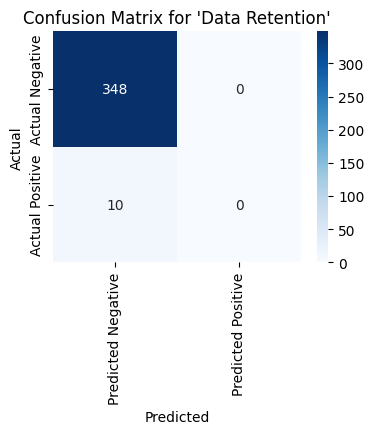

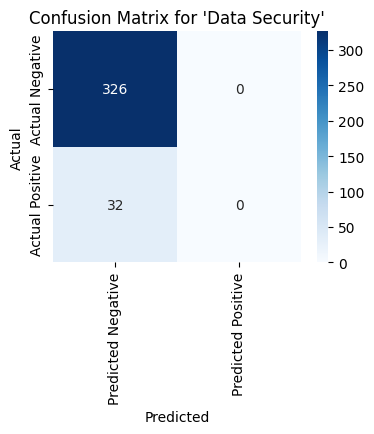

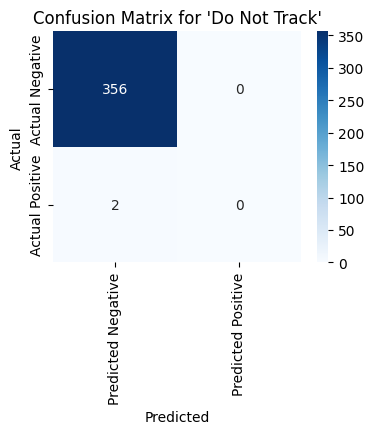

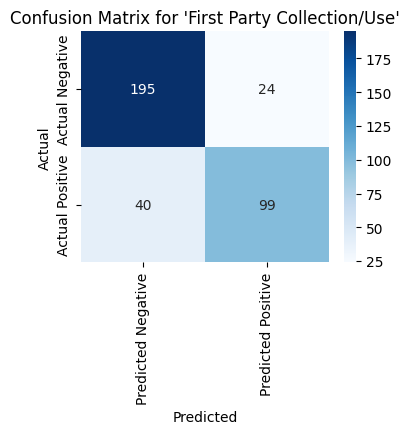

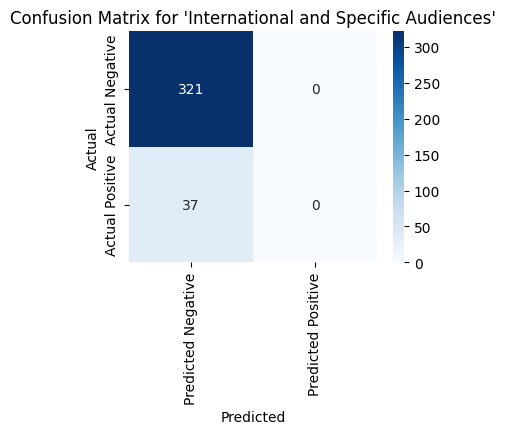

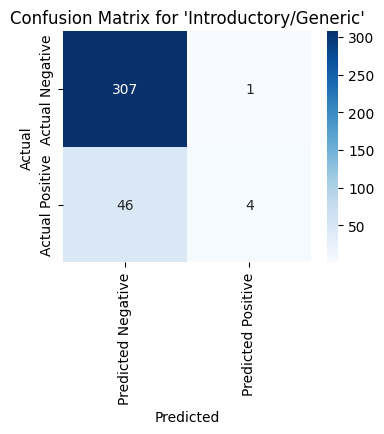

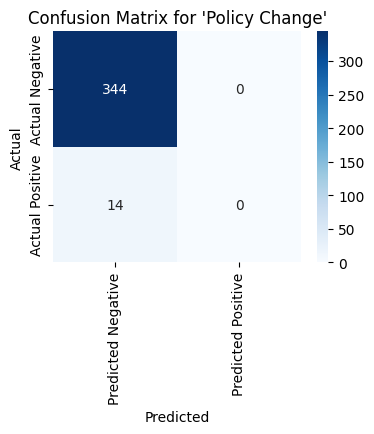

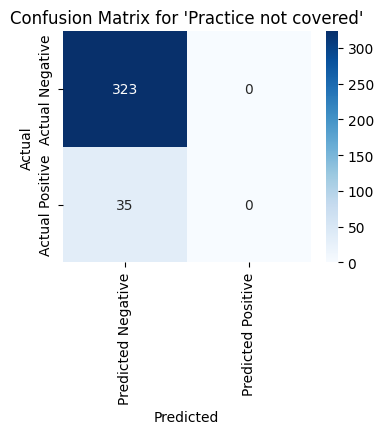

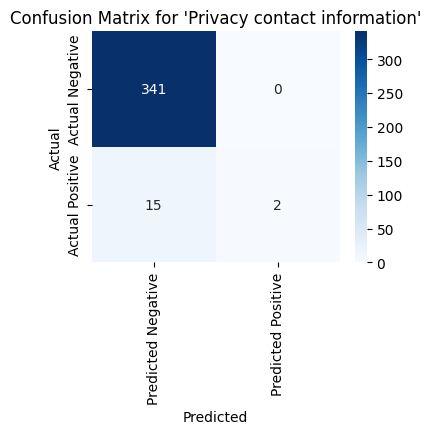

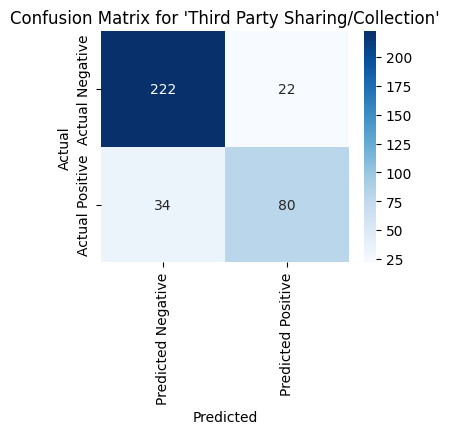

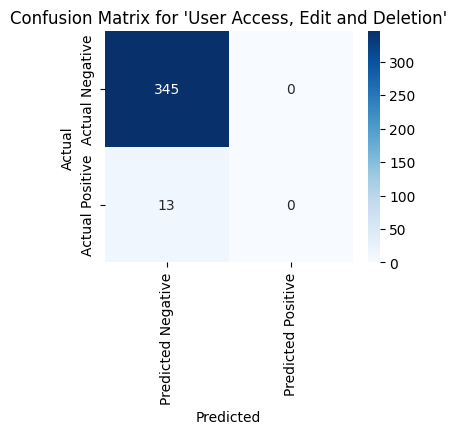

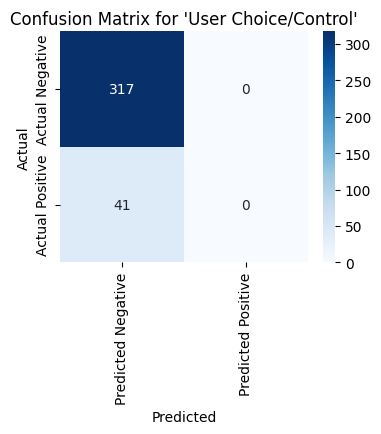

In [ ]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Obtain predictions from the model on the validation dataset
predictions = trainer.predict(dataset_splits["validation"])
logits = predictions.predictions
true_labels = predictions.label_ids

# 3. Convert raw logits to binary predictions using a sigmoid and threshold
# Apply sigmoid to logits
probs = 1 / (1 + np.exp(-logits))
# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
predicted_labels = (probs >= 0.5).astype(int)

print("Predictions obtained and converted to binary labels.")

# 4. Generate and print a classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=all_unique_labels, zero_division=0))

# 5. Generate and print a confusion matrix (multilabel_confusion_matrix for multi-label classification)
print("\nConfusion Matrices for each label:")
# multilabel_confusion_matrix returns one confusion matrix for each label
confusion_matrices = multilabel_confusion_matrix(true_labels, predicted_labels)

# Display each confusion matrix using a heatmap
for i, label_name in enumerate(all_unique_labels):
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrices[i], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Negative", "Predicted Positive"],
                yticklabels=["Actual Negative", "Actual Positive"])
    plt.title(f"Confusion Matrix for '{label_name}'")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


## Final Task

### Subtask:
Summarize the finetuning process, present the evaluation results, and discuss the performance of the finetuned model.


## Summary:

### Data Analysis Key Findings

*   **Training Configuration Refinement**:
    *   During the definition of training arguments, a `TypeError` was encountered due to using `evaluation_strategy` instead of the correct parameter, `eval_strategy`.
    *   A `ValueError` was identified, requiring the `eval_strategy` and `save_strategy` to match when `load_best_model_at_end` is set to `True`.
    *   A `FutureWarning` during `Trainer` initialization prompted a change from using `tokenizer` directly to `processing_class`.
*   **Data Preprocessing for Training**:
    *   An initial `RuntimeError` during training was caused by a type mismatch where the `BCEWithLogitsLoss` expected `torch.float` labels, but the preprocessed dataset provided `torch.long` labels.
    *   This issue was resolved by explicitly casting the multi-hot encoded labels to `float` within the `preprocess_function`.
*   **Model Performance Overview**:
    *   The finetuned model achieved a micro F1-score of 0.5027 on the validation set, with a micro precision of 0.7974 and micro recall of 0.3671. The `eval_loss` was 0.2512 and `eval_roc_auc` was 0.8754.
    *   The `micro avg` in the classification report showed precision of 0.80, recall of 0.37, and f1-score of 0.50 across all classes.
    *   The `macro avg` was significantly lower (precision 0.28, recall 0.13, f1-score 0.15), indicating performance disparities across different labels.
*   **Per-Label Performance**:
    *   Categories such as "First Party Collection/Use" (f1-score: 0.76) and "Third Party Sharing/Collection" (f1-score: 0.74) were the best-performing.
    *   Several labels, including "Data Retention", "Data Security", "Do Not Track", "Policy Change", "Practice not covered", and "User Access, Edit and Deletion", showed 0.00 for precision, recall, and f1-score, suggesting the model failed to predict these classes effectively.
*   **Detailed Analysis**: Individual confusion matrices were generated and visualized for each of the 12 unique labels, providing a granular view of true positives, true negatives, false positives, and false negatives.

### Insights or Next Steps

*   The large discrepancy between micro and macro averaged F1-scores (0.50 vs. 0.15) suggests significant class imbalance or a lack of representative data for certain categories, leading to poor performance on minority classes.
*   Further investigation is needed for the categories where the model achieved an f1-score of 0.00. This could involve collecting more data for these specific labels, re-evaluating the label definitions, or applying techniques like class weighting or oversampling during training to address the imbalance.


# Task
Okay, I will compress the finetuned model directory and provide instructions on how to download it and use it for local inference.

Compress the `./finetuned_model` directory into a zip file.

## Compress Finetuned Model Directory

### Subtask:
Compress the `./finetuned_model` directory into a zip file for easy downloading.


**Reasoning**:
To compress the directory into a zip file, I will use the `zip` command in a code block.



In [ ]:
import shutil

output_filename = 'finetuned_model'
shutil.make_archive(output_filename, 'zip', './finetuned_model')

print(f"Directory './finetuned_model' compressed to '{output_filename}.zip'.")

Directory './finetuned_model' compressed to 'finetuned_model.zip'.


## Download the Finetuned Model

To download the compressed finetuned model, you can use the file browser in the Colab environment or execute the following shell command in a code cell:

```bash
gcloud colab download finetuned_model.zip
```

Alternatively, you can right-click on `finetuned_model.zip` in the Colab file browser (usually on the left sidebar) and select "Download".

## Download the Finetuned Model

To download the compressed finetuned model, you can use the file browser in the Colab environment or execute the following shell command in a code cell:

```bash
gcloud colab download finetuned_model.zip
```

Alternatively, you can right-click on `finetuned_model.zip` in the Colab file browser (usually on the left sidebar) and select "Download".

## Download the Finetuned Model

To download the compressed finetuned model, you can use the file browser in the Colab environment or execute the following shell command in a code cell:

```bash
gcloud colab download finetuned_model.zip
```

Alternatively, you can right-click on `finetuned_model.zip` in the Colab file browser (usually on the left sidebar) and select "Download".

## Final Task

### Subtask:
Provide instructions on how to use the downloaded model for local inference.


## Summary:

### Q&A
The original task requested instructions on how to use the downloaded model for local inference. While the model was compressed and download instructions were provided, specific steps for performing local inference with the downloaded model were not included in the solving process.

### Data Analysis Key Findings
*   The `./finetuned_model` directory was successfully compressed into a zip archive named `finetuned_model.zip`.
*   Instructions were provided to download the `finetuned_model.zip` file using either the Colab file browser or a `gcloud colab download` command.

### Insights or Next Steps
*   The next crucial step is to provide detailed instructions on how to perform local inference using the downloaded `finetuned_model.zip`. This should include steps like unzipping the archive, installing necessary libraries, and example code for loading the model and making predictions.


In [ ]:
!gcloud colab download finetuned_model.zip

ERROR: (gcloud.colab) Invalid choice: 'download'.
Maybe you meant:
  gcloud colab executions
  gcloud colab runtime-templates
  gcloud colab runtimes
  gcloud colab schedules

To search the help text of gcloud commands, run:
  gcloud help -- SEARCH_TERMS


## Final Task

### Subtask:
Provide instructions on how to use the downloaded model for local inference.

**Reasoning**:
To complete the task of providing instructions for local inference, I will create a detailed guide that covers unzipping the model, installing necessary libraries, and providing example Python code for loading the model and making predictions using the `transformers` library.

### Instructions for Local Inference with the Finetuned Model

Here are the steps to use your downloaded `finetuned_model.zip` for local inference:

1.  **Unzip the Model Archive**:
    *   Locate the `finetuned_model.zip` file you downloaded.
    *   Extract its contents to a directory of your choice. Let's assume you extract it to a folder named `my_finetuned_model`.

2.  **Install Required Libraries (if not already installed)**:
    *   Open your terminal or command prompt.
    *   Make sure you have Python installed.
    *   Install `transformers` and `torch` (or `tensorflow` if you prefer, but this model was trained with PyTorch) and `scikit-learn`:
        ```bash
        pip install transformers torch scikit-learn
        ```

3.  **Prepare for Inference with Python**:
    *   Create a new Python script (e.g., `infer_local.py`) or open a Python interpreter.
    *   You'll need the `id2label` mapping that was generated during training to interpret the model's numerical predictions back into meaningful category names. The `id2label` dictionary should be available in the `config.json` file inside your saved model directory, or you can recreate it if you saved `all_unique_labels`.
    *   Here's an example Python code snippet:

    ```python
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
    import torch
    import numpy as np
    import json

    # 1. Define the path to your downloaded and unzipped model directory
    model_path = "./my_finetuned_model" # Adjust this path as necessary

    # 2. Load the tokenizer and model
    # The id2label and label2id mappings are typically saved within the model's config.json
    # When loading from a local directory, transformers automatically picks these up.
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    # Assuming id2label was loaded from the model config, or recreated based on all_unique_labels
    # If the model's config doesn't automatically load id2label (less common for custom heads),
    # you might need to manually load it. For this model, it should be part of the config.
    # Example of extracting from loaded model (it's part of model.config)
    id2label = model.config.id2label
    label2id = model.config.label2id
    all_unique_labels = list(label2id.keys())

    # 3. Create a pipeline for text classification
    classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, return_all_scores=True) # return_all_scores=True for multi-label

    # 4. Example input text
    new_text = "This service uses cookies to track user activity for advertising purposes."

    # 5. Perform inference
    results = classifier(new_text)

    print("\nInference results with the finetuned model (from pipeline):")
    # The pipeline might return results in different formats depending on return_all_scores
    # and model configuration. For multi-label, it usually returns scores for all labels.
    if results and isinstance(results[0], list): # If return_all_scores=True
        sorted_results = sorted(results[0], key=lambda x: x['score'], reverse=True)
        print("  Predicted Categories with scores:")
        for res in sorted_results:
            print(f"    Label: {res['label']}, Score: {res['score']:.4f}")
    else:
        for res in results:
            print(f"    Label: {res['label']}, Score: {res['score']:.4f}")

    # 6. Manual multi-label prediction (for complete control over thresholding)
    inputs = tokenizer(new_text, return_tensors="pt", truncation=True, padding=True)

    # Move inputs to the same device as the model (e.g., CPU or GPU)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.sigmoid(logits)
    predicted_labels_manual = (probs > 0.5).cpu().numpy().astype(int).squeeze() # Use 0.5 threshold

    print("\nManual multi-label prediction for the example text:")
    predicted_categories = [id2label[i] for i, pred in enumerate(predicted_labels_manual) if pred == 1]
    if predicted_categories:
        print(f"  Predicted Categories: {predicted_categories}")
    else:
        print("  No categories predicted above threshold.")

    ```

Remember to replace `./my_finetuned_model` with the actual path to your extracted model directory. You can adjust the `new_text` variable to test different privacy policy statements.

In [ ]:
from google.colab import files
files.download('finetuned_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
gcloud colab download finetuned_model.zip

SyntaxError: invalid syntax (ipython-input-530910925.py, line 1)